In [62]:
%load_ext autoreload
%autoreload 2

import math
from typing import Any, Optional

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import wandb

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Model output

In [150]:
def load_run(run: wandb.apis.public.Run) -> Optional[dict[str, Any]]:
    if "entropy_rmse" not in run.summary:
        return None
    _, wq = run.config["quantisation"]
    f = wq["format"]
    group, = f["group_shapes"]
    efmt = f["element_format"]
    if efmt["_type"] == "fp":
        efmt_str = f"E{efmt['exponent_bits']}M{efmt['mantissa_bits']}"
        efmt_type = "fp"
    if efmt["_type"] == "int":
        efmt_str = f"E0M{efmt['bits_'] - 1}"
        efmt_type = "int"
    return dict(
        group_size=math.prod(group),
        scale_mantissa=f["scale_format"]["mantissa_bits"],
        element_format=efmt_str,
        element_type=efmt_type,
        n_bytes=run.summary["n_bytes"],
        n_params=run.summary["n_params"],
        entropy_rmse=run.summary["entropy_rmse"],
        entropy_rmse_stderr=run.summary["entropy_rmse_stderr"],
    )

api = wandb.Api()
df = (pd.DataFrame.from_records(filter(None, [
    load_run(run)
    for run in api.runs("graphcore/llama-mobile", {"config.name": "202412-scaling-exponents"})
]))
    .pipe(lambda d: d.assign(bpw=8 * d.n_bytes / d.n_params))
)
print(len(df), "runs")
display(df.head())

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
120 runs


,group_size,scale_mantissa,element_format,element_type,n_bytes,n_params,entropy_rmse,entropy_rmse_stderr,bpw
0,8,0,E2M1,fp,6940925510,10670220835,0.286015,0.005275,5.203960
1,8,0,E0M3,int,6940925510,10670220835,0.326324,0.005455,5.203960
2,8,0,E2M2,fp,8265018950,10670220835,0.143287,0.002830,6.196699
3,8,0,E0M4,int,8265018950,10670220835,0.135695,0.002901,6.196699
4,8,1,E0M3,int,7106437190,10670220835,0.262805,0.004979,5.328053


In [151]:
df.groupby(["group_size", "scale_mantissa"]).bpw.count().to_frame().T

group_size     8                  16            ... 64           128           \
scale_mantissa   0  1  2  3  4  7   0  1  2  3  ...   2  3  4  7   0  1  2  3   
bpw              4  4  4  4  4  4   4  4  4  4  ...   4  4  4  4   4  4  4  4   

group_size            
scale_mantissa  4  7  
bpw             4  4  

[1 rows x 30 columns]

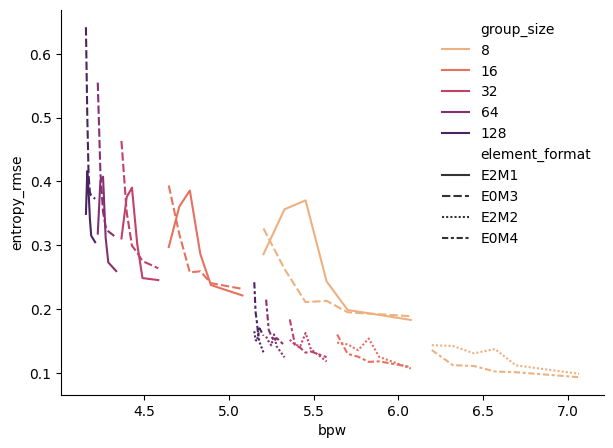

In [154]:
_, ax = plt.subplots(figsize=(7, 5))
sns.lineplot(data=df, y="entropy_rmse", x="bpw", style="element_format", hue="group_size", hue_norm=matplotlib.colors.LogNorm(), palette="flare", ax=ax);

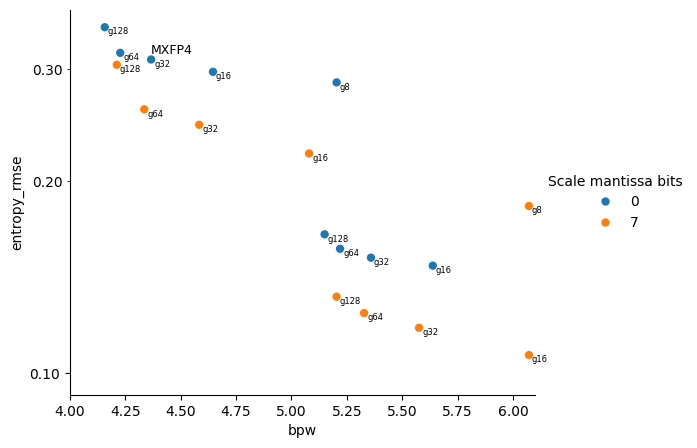

In [235]:
_, ax = plt.subplots(figsize=(6, 5))
g = df[df.scale_mantissa.isin([0, 7]) & (df.element_type=="fp")]
sns.scatterplot(data=g.assign(scale_mantissa=df.scale_mantissa.apply(str)),
                y="entropy_rmse", x="bpw", hue="scale_mantissa", linewidth=0, ax=ax)
df_mxfp4 = g.pipe(lambda d: d[(d.element_format=="E2M1") & (d.group_size==32) & (d.scale_mantissa==0)])
ax.annotate("MXFP4", [df_mxfp4.bpw.iloc[0], df_mxfp4.entropy_rmse.iloc[0]], xytext=(0, 3), textcoords="offset pixels", va="bottom", fontsize=9)
for _, s in g.iterrows():
    ax.annotate(f"g{s.group_size}", [s.bpw, s.entropy_rmse], xytext=(3, 0), textcoords="offset pixels", va="top", fontsize=6, zorder=-1)
ax.set_yscale("log")
ax.yaxis.set_major_formatter("{x:.2f}")
ax.yaxis.set_minor_formatter("{x:.2f}")
ax.set_xlim((4, 6.1))
ax.legend(title="Scale mantissa bits", bbox_to_anchor=(1, .5), loc="center left");

## Bench test

In [ ]:
import torch
from torch import Tensor
import training.quantisation as Q
import torchao.prototype.mx_formats.mx_tensor as torchao_mx


def snr(t: Tensor, q: Tensor) -> Tensor:
    return t.pow(2).mean() / q.sub(t).pow_(2).mean()


def evaluate(element_format: str, scale_mantissa: int, group_size: int,
             data_std: float, use_torchao: bool, seed: int = 100) -> dict[str, Any]:
    torch.manual_seed(seed)
    x = data_std * torch.randn(2**20)
    if use_torchao:
        assert scale_mantissa == 0
        e_fmt = {"E2M1": "fp4_e2m1", "E2M3": "fp6_e2m3", "E3M2": "fp6_e2m3"}[element_format]
        scale, data = torchao_mx.to_mx(x, e_fmt, group_size)
        qx = torchao_mx.to_dtype(data, scale, e_fmt, group_size, torch.float32)
        bits = math.prod(x.shape) * ({"E2M1": 4, "E2M3": 6, "E3M2": 6}[element_format] + (1/group_size) * 8)
    else:
        fmt = Q.LinearScalingFormat(
            element_format=Q.parse(element_format),
            group_shapes=[(group_size,)],
            scale_format=Q.FPFormat_NoSign(8, scale_mantissa, "to_inf"),
            scale_combiner=None,
        )
        qx = fmt.quantise(x)
        bits = fmt.count_bits(x.shape)
    return dict(
        snr=snr(x, qx).item(),
        bpw=bits / math.prod(x.shape),
    )

dfb = pd.DataFrame.from_dict(
    dict(**args, **evaluate(**args))
    for data_std in (2**torch.linspace(0, 2, 17)).tolist()
    for scale_mantissa in range(8)
    for element_format in ["E2M1", "E0M3", "E2M2", "E0M4"]
    for group_size in [8, 16, 32, 64, 128]
    for use_torchao in [False, True]
    for args in [dict(
        element_format=element_format,
        scale_mantissa=scale_mantissa,
        group_size=group_size,
        data_std=data_std,
        use_torchao=use_torchao,
    )]
    if not use_torchao or (scale_mantissa == 0 and element_format in ("E2M1", "E2M3", "E3M2"))
)
dfb = dfb.pipe(lambda d: d.assign(element_type=d.element_format.apply(lambda s: "int" if s.startswith("E0") else "fp")))
display(dfb.head())

,element_format,scale_mantissa,group_size,data_std,use_torchao,snr,bpw
0,E2M1,0,8,1.0,False,82.581978,5.00
1,E2M1,0,8,1.0,True,68.706345,5.00
2,E2M1,0,16,1.0,False,78.617081,4.50
3,E2M1,0,16,1.0,True,71.943527,4.50
4,E2M1,0,32,1.0,False,75.050789,4.25


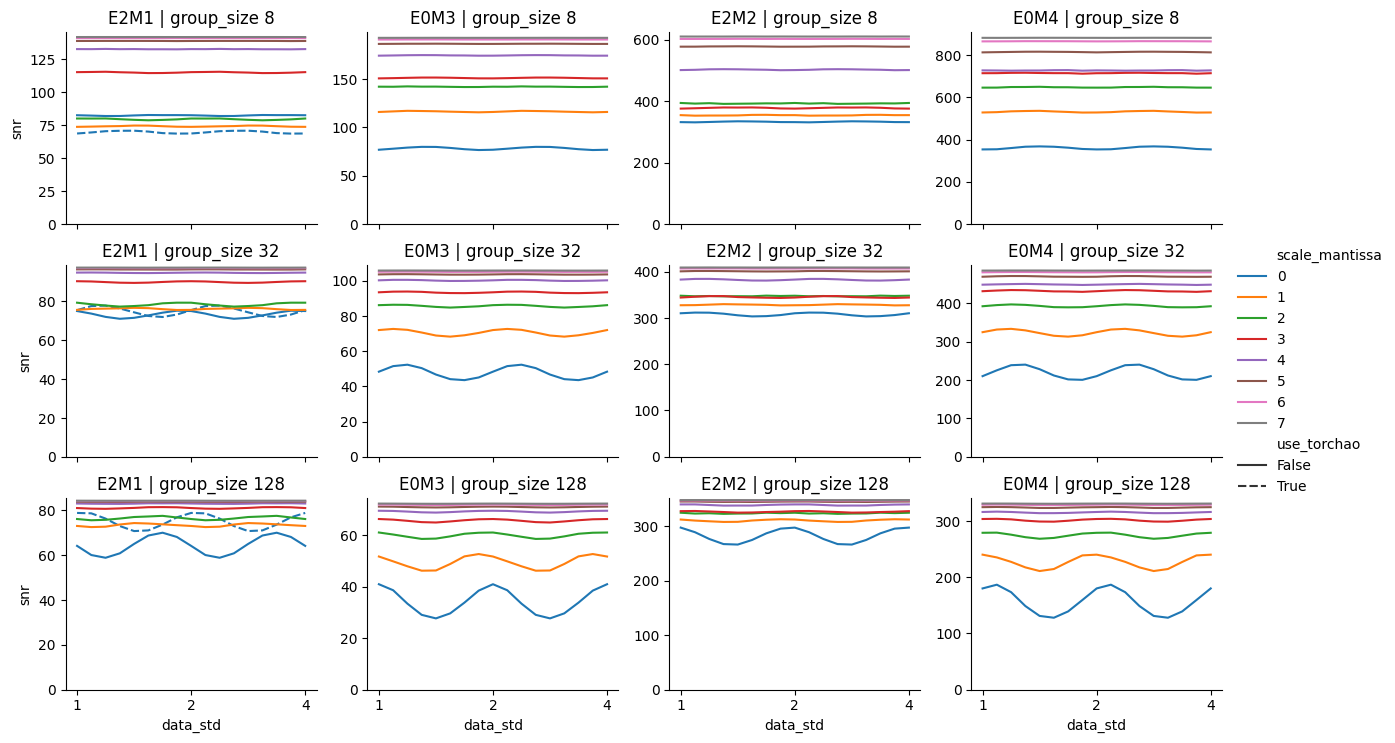

In [100]:
g = sns.relplot(data=dfb.assign(scale_mantissa=dfb.scale_mantissa.apply(str)),
                y="snr", x="data_std", hue="scale_mantissa", style="use_torchao",
                row="group_size", row_order=[8, 32, 128], col="element_format",
                kind="line", height=2.5, aspect=1.25, facet_kws=dict(sharey=False))
for (group_size, element_format), ax in g.axes_dict.items():
    ax.set_title(f"{element_format} | group_size {group_size}")
    ax.set_ylim((0, ax.get_ylim()[1]))
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter("{x:.0f}")

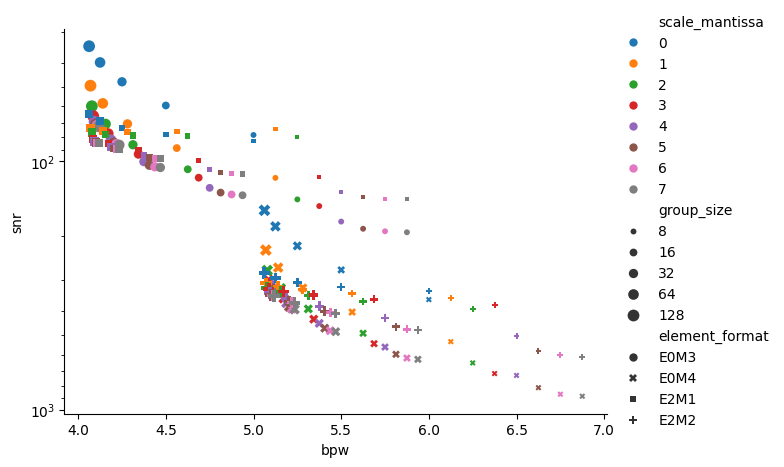

In [160]:
dfba = dfb.groupby(["element_format", "element_type", "scale_mantissa", "group_size", "use_torchao"]).mean().reset_index()
_, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=dfba.assign(scale_mantissa=dfba.scale_mantissa.apply(str))[~dfba.use_torchao],
                y="snr", x="bpw", hue="scale_mantissa", style="element_format",
                size="group_size", size_norm=matplotlib.colors.LogNorm(), linewidth=0, ax=ax)
ax.set_yscale("log")
ax.invert_yaxis()
ax.legend(bbox_to_anchor=(1, .5), loc="center left");

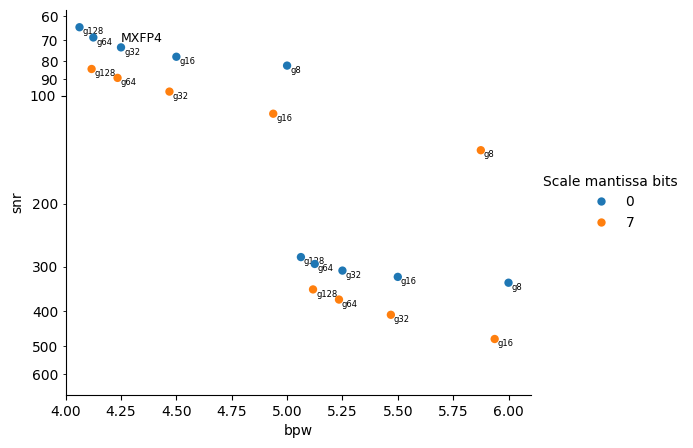

In [233]:
_, ax = plt.subplots(figsize=(6, 5))
g = dfba[~dfba.use_torchao & dfba.scale_mantissa.isin([0, 7]) & (dfba.element_type == "fp")]
sns.scatterplot(data=g.assign(scale_mantissa=dfba.scale_mantissa.apply(str)),
                y="snr", x="bpw", hue="scale_mantissa", linewidth=0, ax=ax)
df_mxfp4 = g.pipe(lambda d: d[(d.element_format=="E2M1")&(d.group_size==32)&(d.scale_mantissa==0)])
ax.annotate("MXFP4", [df_mxfp4.bpw.iloc[0], df_mxfp4.snr.iloc[0]], xytext=(0, 3), textcoords="offset pixels", va="bottom", fontsize=9)
for _, s in g.iterrows():
    ax.annotate(f"g{s.group_size}", [s.bpw, s.snr], xytext=(3, 0), textcoords="offset pixels", va="top", fontsize=6, zorder=-1)
ax.set_yscale("log")
ax.set_xlim((4, 6.1))
ax.yaxis.set_major_formatter("{x:.0f}")
ax.yaxis.set_minor_formatter("{x:.0f}")
ax.invert_yaxis()
ax.legend(title="Scale mantissa bits", bbox_to_anchor=(1, .5), loc="center left");

## Intuition

How much does the MX scale round up? What is that worth (considering an integer element format)?

In [ ]:
(2/torch.linspace(1, 2, 10000)).mean()

tensor(1.3863)

In [250]:
2*torch.log(torch.tensor(2))

tensor(1.3863)

In [248]:
torch.log2(2*torch.log(torch.tensor(2)))

tensor(0.4712)